# Medical Insurance Cost Prediction — Random Forest Regressor (Bagging Ensemble)

**Dataset:** [Medical Insurance Cost Prediction](https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction) (Mohan Krishna Thalla)

**Goal:** Predict **annual medical cost** using a **Random Forest Regressor**. Random Forest is a **bagging** (Bootstrap AGGregatING) ensemble: it trains many decision trees on bootstrap samples of the data and averages their predictions, with extra randomness from feature subsampling at each split.

**Run in:** Google Colab (Runtime → Run all, or step through cells).

## 1. Load the CSV — Google Drive (no Kaggle token) or Kaggle

### Option A — Google Drive (recommended if you already downloaded the CSV)

1. Upload the dataset `.csv` to your Google Drive (any folder).
2. In the next cell, set `USE_GOOGLE_DRIVE = True` and set `DRIVE_CSV_PATH` to the full path after mounting.
3. Typical paths look like `/content/drive/MyDrive/folder_name/your_file.csv`. You can copy the path from Drive’s file context menu or browse under `/content/drive/MyDrive/` after mounting.
4. Run the cell; authorize Colab to access Drive when asked.

### Option B — Kaggle API

Set `USE_GOOGLE_DRIVE = False` in the next cell, then run it. You will need `kaggle.json` (Kaggle → Account → **Create New API Token**) or Colab **Secrets** as described in the optional block inside that cell.

In [2]:
import glob
import os
import subprocess

import pandas as pd

# ----- Choose data source -----
USE_GOOGLE_DRIVE = True
# Full path to your CSV after Drive is mounted (edit folder + filename)
DRIVE_CSV_PATH = "/content/drive/MyDrive/ML_Project/medical_insurance.csv"


def _sh(cmd: str) -> None:
    subprocess.run(cmd, shell=True, check=True)


if USE_GOOGLE_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    df = pd.read_csv(DRIVE_CSV_PATH)
    print("Loaded from Google Drive:", DRIVE_CSV_PATH)
else:
    _sh("pip install -q kaggle")
    if not os.path.exists("/root/.kaggle/kaggle.json"):
        from google.colab import files

        os.makedirs("/root/.kaggle", exist_ok=True)
        uploaded = files.upload()  # upload kaggle.json
        _sh("mv -f kaggle.json /root/.kaggle/kaggle.json")
        _sh("chmod 600 /root/.kaggle/kaggle.json")

    # Optional: Colab Secrets instead of upload (uncomment)
    # from google.colab import userdata
    # os.makedirs("/root/.kaggle", exist_ok=True)
    # open("/root/.kaggle/kaggle.json", "w").write(
    #     '{"username":"' + userdata.get("KAGGLE_USERNAME") + '","key":"' + userdata.get("KAGGLE_KEY") + '"}'
    # )
    # _sh("chmod 600 /root/.kaggle/kaggle.json")

    _sh(
        "kaggle datasets download -d mohankrishnathalla/medical-insurance-cost-prediction"
    )
    _sh("unzip -o medical-insurance-cost-prediction.zip -d medical_insurance_data")
    csv_paths = glob.glob("medical_insurance_data/**/*.csv", recursive=True)
    if not csv_paths:
        csv_paths = glob.glob("**/*.csv", recursive=True)
    assert csv_paths, "No CSV found after Kaggle download."
    df = pd.read_csv(csv_paths[0])
    print("Loaded from Kaggle extract:", csv_paths[0])

df.head()

Mounted at /content/drive
Loaded from Google Drive: /content/drive/MyDrive/ML_Project/medical_insurance.csv


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


## 2. Imports

`df` was created in section 1. Run that cell first.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

assert "df" in globals(), "Run section 1 first to create `df`."


In [4]:
print(df.shape)
print(df.dtypes)
df.info()
df.describe(include="all")

(100000, 54)
person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                       int64
copay       

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,100000,100000,100000,1.000000e+05,100000,100000,100000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
unique,NaN,NaN,3,5,3,NaN,6,4,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,South,Urban,NaN,Bachelors,Married,Employed,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,49193,28029,60019,NaN,27996,53252,55269,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,50000.500000,47.521500,NaN,NaN,NaN,4.987390e+04,NaN,NaN,NaN,2.430900,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,NaN,NaN,NaN,4.680021e+04,NaN,NaN,NaN,1.075126,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,NaN,NaN,NaN,1.100000e+03,NaN,NaN,NaN,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,NaN,NaN,NaN,2.110000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,NaN,NaN,NaN,3.620000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,NaN,NaN,NaN,6.220000e+04,NaN,NaN,NaN,3.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000


## 3. Target column: `annual_medical_cost`

Some versions of this dataset name the target **`charges`**. This cell picks **`annual_medical_cost`** if present, otherwise **`charges`** (and renames for consistency).

In [5]:
TARGET_CANDIDATES = ["annual_medical_cost", "charges", "Annual_medical_cost"]
target_col = next((c for c in TARGET_CANDIDATES if c in df.columns), None)
if target_col is None:
    raise ValueError(
        "Could not find target column. Columns are: " + str(list(df.columns))
    )

if target_col != "annual_medical_cost":
    df = df.rename(columns={target_col: "annual_medical_cost"})

print("Target column:", "annual_medical_cost")
df["annual_medical_cost"].describe()

Target column: annual_medical_cost


,annual_medical_cost
count,100000.000000
mean,3009.451907
std,3127.462822
min,55.550000
25%,1175.117500
50%,2082.575000
75%,3707.957500
max,65724.900000


In [6]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
if missing.sum() == 0:
    print("No missing values.")

Missing values per column:
 alcohol_freq    30083
dtype: int64


## 4. Features vs target, train/val/test split (70% / 10% / 20%), and model

Numeric columns are passed through; low-cardinality categoricals are **one-hot encoded**.

The data is split into **70% training**, **10% validation**, and **20% test** (same random seed for reproducibility). The pipeline is **fit only on the training set**. Use validation to sanity-check generalization during experiments; use the test set for final reporting.

In [8]:
y = df["annual_medical_cost"].values

# Ignore these columns in feature selection (if present in dataset)
DROP_FEATURES = [
    "person_id",
    "policy_term_years",
    "policy_changes_last_2yrs",
    "provider_quality",
    "annual_premium",
    "monthly_premium",
    "claims_count",
    "avg_claim_amount",
    "total_claims_paid",
    "risk_score",
]

existing_drop_features = [c for c in DROP_FEATURES if c in df.columns]
X = df.drop(columns=["annual_medical_cost", *existing_drop_features], errors="ignore")

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Dropped features:", existing_drop_features)
print("Using feature count:", X.shape[1])
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Dropped features: ['person_id', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'risk_score']
Using feature count: 43
Numeric: ['age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']
Categorical: ['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']


In [16]:
RANDOM_STATE = 42

# 70% train, 30% held out — then split held-out into 10% val and 20% test (of full data)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=2 / 3,
    random_state=RANDOM_STATE,
)

n_total = len(X)
print(
    f"Train:      {len(X_train):5d} ({100 * len(X_train) / n_total:.1f}%)\n"
    f"Validation: {len(X_val):5d} ({100 * len(X_val) / n_total:.1f}%)\n"
    f"Test:       {len(X_test):5d} ({100 * len(X_test) / n_total:.1f}%)"
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)


def build_rf_pipeline(params=None):
    params = params or {}
    rf = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params,
    )
    return Pipeline([("preprocess", clone(preprocess)), ("regressor", rf)])


param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [8, 12, 16],
    "min_samples_leaf": [2, 5, 10],
    "min_samples_split": [5, 10, 20],
    "max_features": ["sqrt", 0.5],
}

n_grid = int(np.prod([len(v) for v in param_grid.values()]))
print(
    f"Hyperparameter grid: {n_grid} combinations (each trains a full Random Forest). "
    "Do not store every fitted model—only metrics—then refit once with best params."
)

search_results = []
for params in ParameterGrid(param_grid):
    candidate_model = build_rf_pipeline(params)
    candidate_model.fit(X_train, y_train)

    train_pred = candidate_model.predict(X_train)
    val_pred = candidate_model.predict(X_val)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)

    search_results.append(
        {
            **params,
            "train_rmse": train_rmse,
            "val_rmse": val_rmse,
            "train_r2": train_r2,
            "val_r2": val_r2,
            "generalization_gap": train_r2 - val_r2,
        }
    )
    del candidate_model  # free memory; old code kept 100+ full models in RAM

results_df = pd.DataFrame(search_results).sort_values(
    by=["val_rmse", "generalization_gap", "train_rmse"],
    ascending=[True, True, True],
).reset_index(drop=True)

best_result = results_df.iloc[0]
best_params = {
    key: best_result[key]
    for key in ["n_estimators", "max_depth", "min_samples_leaf", "min_samples_split", "max_features"]
}
model = build_rf_pipeline(best_params)
model.fit(X_train, y_train)

print("Chosen Random Forest hyperparameters:")
print(best_params)
print(
    f"Validation RMSE: {best_result['val_rmse']:,.2f} | "
    f"Validation R²: {best_result['val_r2']:.4f} | "
    f"Train–Validation R² gap: {best_result['generalization_gap']:.4f}"
)

display(
    results_df[
        [
            "n_estimators",
            "max_depth",
            "min_samples_leaf",
            "min_samples_split",
            "max_features",
            "train_rmse",
            "val_rmse",
            "train_r2",
            "val_r2",
            "generalization_gap",
        ]
    ].head(10)
)


Train:      70000 (70.0%)
Validation: 10000 (10.0%)
Test:       20000 (20.0%)
Hyperparameter grid: 108 combinations (each trains a full Random Forest). Do not store every fitted model—only metrics—then refit once with best params.
Chosen Random Forest hyperparameters:
{'n_estimators': np.int64(300), 'max_depth': np.int64(8), 'min_samples_leaf': np.int64(2), 'min_samples_split': np.int64(5), 'max_features': 0.5}
Validation RMSE: 2,837.36 | Validation R²: 0.1500 | Train–Validation R² gap: 0.0898


,n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features,train_rmse,val_rmse,train_r2,val_r2,generalization_gap
0,300,8,2,5,0.5,2707.596774,2837.360907,0.239718,0.149961,0.089756
1,300,8,2,20,0.5,2736.800276,2837.438678,0.223229,0.149915,0.073314
2,300,8,10,5,0.5,2745.617415,2837.492788,0.218216,0.149882,0.068333
3,300,8,10,10,0.5,2745.617415,2837.492788,0.218216,0.149882,0.068333
4,300,8,10,20,0.5,2745.617415,2837.492788,0.218216,0.149882,0.068333
5,300,12,10,20,sqrt,2687.526029,2837.707811,0.250948,0.149754,0.101194
6,300,12,10,5,sqrt,2687.526029,2837.707811,0.250948,0.149754,0.101194
7,300,12,10,10,sqrt,2687.526029,2837.707811,0.250948,0.149754,0.101194
8,300,8,5,20,0.5,2740.439553,2837.795742,0.221162,0.149701,0.071461
9,300,8,2,10,0.5,2720.080003,2837.861177,0.232691,0.149662,0.083029


## 5. Evaluation - statistics and graphs

**Metrics:** MAE, MSE, RMSE, and R2 on **train**, **validation**, and **test** for the **tuned** random forest.

**Overfitting check:** compare train vs validation/test. A healthy model should still do best on train, but the gap should be noticeably smaller than the untuned model.

**Plots:** metric comparison, actual vs predicted for each split, and residual diagnostics on the **test** set.


All splits metrics:
                  MAE            MSE       RMSE     R²
Split                                                 
train      1,724.7173 7,331,080.2924 2,707.5968 0.2397
validation 1,775.3303 8,050,616.9158 2,837.3609 0.1500
test       1,776.4302 8,632,856.0815 2,938.1722 0.1714

Train–Validation R² gap: 0.0898
Interpretation: the train and validation scores are reasonably close, so the fit is more balanced.

Test set metrics (requested):
MAE:  1,776.4302
MSE:  8,632,856.0815
RMSE: 2,938.1722
R²:   0.1714


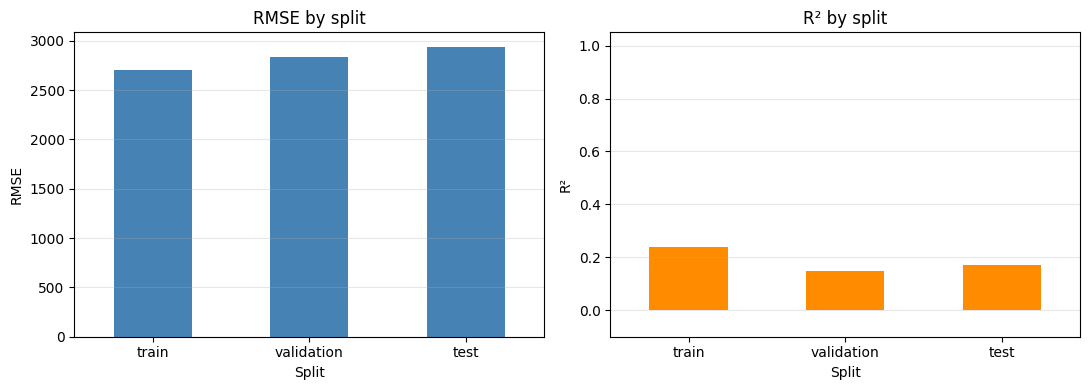

In [17]:
def eval_split(name, y_true, y_hat):
    mae = mean_absolute_error(y_true, y_hat)
    mse = mean_squared_error(y_true, y_hat)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_hat)
    return {"Split": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R²": r2}


y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)
y_pred_test = model.predict(X_test)

metrics_rows = [
    eval_split("train", y_train, y_pred_train),
    eval_split("validation", y_val, y_pred_val),
    eval_split("test", y_test, y_pred_test),
]
metrics_df = pd.DataFrame(metrics_rows).set_index("Split")

train_val_gap = metrics_df.loc["train", "R²"] - metrics_df.loc["validation", "R²"]

print("All splits metrics:")
print(metrics_df.to_string(float_format=lambda v: f"{v:,.4f}"))
print(f"\nTrain–Validation R² gap: {train_val_gap:.4f}")

if train_val_gap > 0.15:
    print("Interpretation: the model is still overfitting (train performance is much better than validation).")
elif metrics_df.loc["train", "R²"] < 0.20 and metrics_df.loc["validation", "R²"] < 0.20:
    print("Interpretation: the model is more likely underfitting (both train and validation scores are low).")
else:
    print("Interpretation: the train and validation scores are reasonably close, so the fit is more balanced.")

print("\nTest set metrics (requested):")
test_row = metrics_df.loc["test"]
print(f"MAE:  {test_row['MAE']:,.4f}")
print(f"MSE:  {test_row['MSE']:,.4f}")
print(f"RMSE: {test_row['RMSE']:,.4f}")
print(f"R²:   {test_row['R²']:,.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
metrics_df["RMSE"].plot(kind="bar", ax=axes[0], color="steelblue", rot=0)
axes[0].set_title("RMSE by split")
axes[0].set_ylabel("RMSE")
axes[0].grid(axis="y", alpha=0.3)

metrics_df["R²"].plot(kind="bar", ax=axes[1], color="darkorange", rot=0)
axes[1].set_title("R² by split")
axes[1].set_ylabel("R²")
axes[1].set_ylim(min(-0.1, metrics_df["R²"].min() - 0.05), 1.05)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


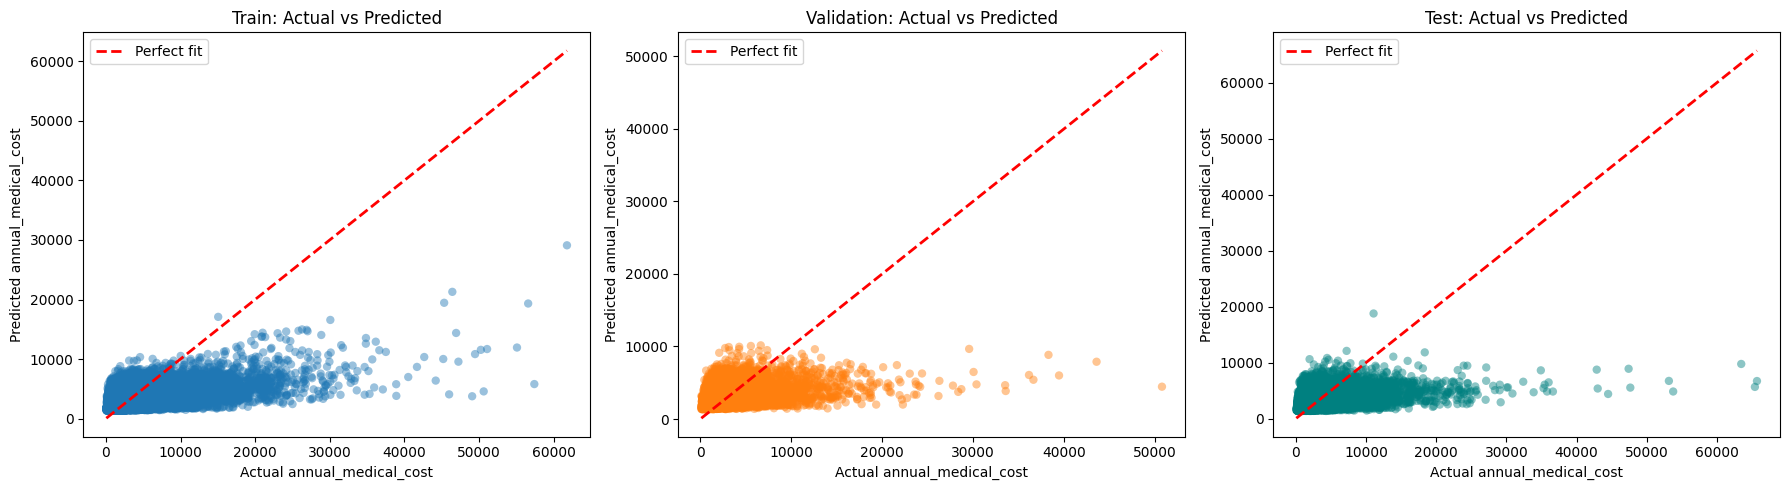

In [18]:
# Prediction vs Actual plots for all splits
split_data = [
    ("Train", y_train, y_pred_train, "tab:blue"),
    ("Validation", y_val, y_pred_val, "tab:orange"),
    ("Test", y_test, y_pred_test, "teal"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_true, y_hat, color) in zip(axes, split_data):
    ax.scatter(y_true, y_hat, alpha=0.45, edgecolors="none", color=color)
    lo = min(y_true.min(), y_hat.min())
    hi = max(y_true.max(), y_hat.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=2, label="Perfect fit")
    ax.set_title(f"{name}: Actual vs Predicted")
    ax.set_xlabel("Actual annual_medical_cost")
    ax.set_ylabel("Predicted annual_medical_cost")
    ax.legend()

plt.tight_layout()
plt.show()


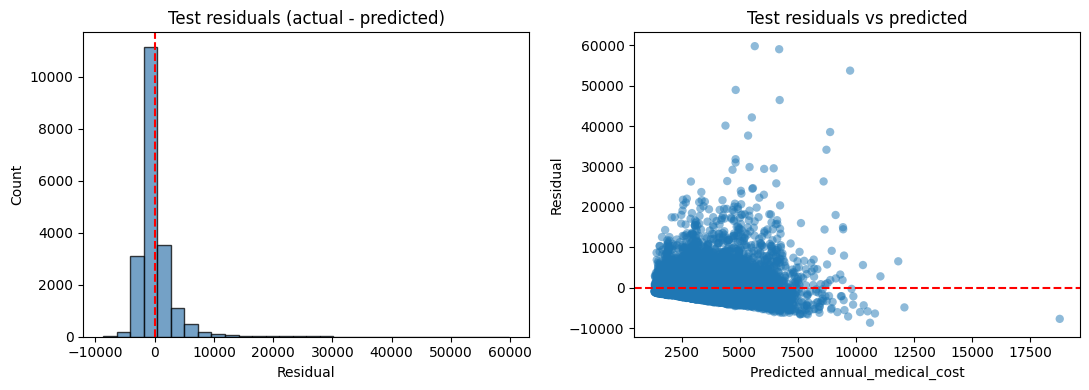

In [19]:
# Residuals on the test set: distribution and vs predicted value
residuals_test = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(residuals_test, bins=30, edgecolor="black", alpha=0.75, color="steelblue")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Test residuals (actual - predicted)")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Count")

axes[1].scatter(y_pred_test, residuals_test, alpha=0.5, edgecolors="none")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Test residuals vs predicted")
axes[1].set_xlabel("Predicted annual_medical_cost")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


## 6. Feature importance (after preprocessing)

Importances are taken from the fitted `RandomForestRegressor` inside the pipeline.

,feature,importance
15,num__chronic_count,0.215340
31,num__is_high_risk,0.162848
7,num__days_hospitalized_last_3yrs,0.137584
58,cat__smoker_Current,0.056459
6,num__hospitalizations_last_3yrs,0.053089
5,num__visits_last_year,0.041429
0,num__age,0.035129
4,num__bmi,0.029082
1,num__income,0.024592
60,cat__smoker_Never,0.024384


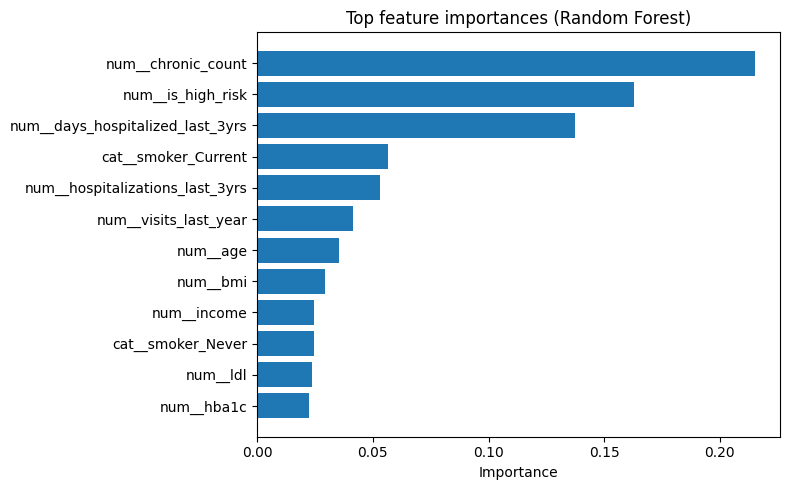

In [20]:
fitted_ct = model.named_steps["preprocess"]
feature_names = fitted_ct.get_feature_names_out()
importances = model.named_steps["regressor"].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False)
display(imp_df.head(15))

top = imp_df.head(12)
plt.figure(figsize=(8, 5))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top feature importances (Random Forest)")
plt.tight_layout()
plt.show()

## 7. (Optional) Pure bagging baseline — `BaggingRegressor`

Random Forest is **bagging + random feature subsets**. For comparison, you can train **plain bagging** of decision trees (same bootstrap idea, all features at each split).

In [21]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

base_tree = DecisionTreeRegressor(random_state=42)
bag = BaggingRegressor(
    estimator=base_tree,
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

# Fresh preprocessor so we don't refit the same object used by `model`
bag_pipeline = Pipeline([("preprocess", clone(preprocess)), ("regressor", bag)])
bag_pipeline.fit(X_train, y_train)
y_bag_val = bag_pipeline.predict(X_val)
y_bag_test = bag_pipeline.predict(X_test)

print("BaggingRegressor (Decision Trees)")
print(
    "Validation — RMSE:",
    np.sqrt(mean_squared_error(y_val, y_bag_val)),
    "  R²:",
    r2_score(y_val, y_bag_val),
)
print(
    "Test — RMSE:",
    np.sqrt(mean_squared_error(y_test, y_bag_test)),
    "  R²:",
    r2_score(y_test, y_bag_test),
)

BaggingRegressor (Decision Trees)
Validation — RMSE: 2917.907249814372   R²: 0.10101504756190494
Test — RMSE: 3005.9501510437367   R²: 0.13277768005040835
